This notebook is used for Data Acquisition of a Rubidium Ion source impinging on a MagneTOF detector. This run is a control for further efficiency tests of PCB RFQs and a PCB Switchyard.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyvisa
import pyvisa_py
import zeroconf
import time
import datetime
import os

In [14]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('USB0::1689::1032::C071283::0::INSTR',)


In [4]:
# List all detected VISA Instruments
# Finds oscilloscope's resource string
# NI ID: 

def list_instruments():
    rm = pyvisa.ResourceManager()
    resources = rm.list_resources()
    if not resources:
        print("No VISA instruments found.")
    else:
        print("Detected VISA Instruments:")
        for resource in resources:
            print(resource)
    
    return resources

list_instruments()

Detected VISA Instruments:
USB0::1689::1032::C071283::0::INSTR


('USB0::1689::1032::C071283::0::INSTR',)

In [20]:
# Configuration

# On Oscilliscope, set:
#  Input Impedance to 50 ohms on MagneTOF channel.
#  Input Impediance to 1M ohm on Aperture Current channel.
#  Probe Attentuation to 1x

# VISA Resource string for the connected instrument
VISA_RESOURCE = "USB0::1689::1032::C071283::0::INSTR"

# Experiment phase identifier
# Phase1: Control group (Rubidium Source and MagneTOF)
# Phase2: PCB RFQ
# Phase3: PCB RFQ + Switchyard
# Phase4: PCB RFQ + 90-degree bend Switchyard
EXPERIMENT_PHASE = "phase1_control"

# MagneTOF signal Channel on the oscilloscope 
MAGNETOF_CHANNEL = 1

# Aperture Current Channel on the oscilloscope
APERTURE_CURRENT_CHANNEL = 2

# Trigger level (volts - set above noise floor)
# MagneTOF pulses are negative-going
TRIGGER_LEVEL = -0.020 # -20mV starting point for MagneTOF

# Voltage scale per division for MagneTOF signal (volts/division)
MAGNETOF_VOLTAGE_SCALE = 0.005 # 20mV/div

# Voltage scale per division for Aperture Current signal (volts/division)
APERTURE_CURRENT_VOLTAGE_SCALE = 1.0 # 1 V/div

# Timebase scale per division (seconds/division)
TIMEBASE_SCALE = 0.00000001 # 10ns/div

# Number of measurement samples per run
NUM_SAMPLES = 250

# Time between samples (seconds)
SAMPLE_INTERVAL = 1.0

# Output directory for saving data and plots
OUTPUT_DIR = "Results"

In [17]:
# Instrument Setup

def connect(resource_string, timeout_ms = 10000):
    rm = pyvisa.ResourceManager()
    scope = rm.open_resource(resource_string)
    scope.timeout = timeout_ms

    # Verify connection
    scope.write("*cls")
    idn = scope.query("*idn?")
    print(f"Connected to: {idn.strip()}")
    return scope

def setup_scope(scope):
    print("Configuring oscilloscope settings...")

    scope.write("*rst")
    scope.write("*cls")
    time.sleep(3)  # Tektronix RST command takes a few seconds to complete

    # Turn off all channels then enable only what we need
    for ch in range(1, 5):
        scope.write(f"select:ch{ch} off")

    # MagneTOF channel
    scope.write(f"select:ch{MAGNETOF_CHANNEL} on")
    scope.write(f"ch{MAGNETOF_CHANNEL}:coupling dc")
    scope.write(f"ch{MAGNETOF_CHANNEL}:termination fifty")
    scope.write(f"ch{MAGNETOF_CHANNEL}:scale {MAGNETOF_VOLTAGE_SCALE}")
    scope.write(f"ch{MAGNETOF_CHANNEL}:position 3")  # shifts trace up 3 divisions, display-only

# Aperture channel
    if APERTURE_CURRENT_CHANNEL is not None:
        scope.write(f"select:ch{APERTURE_CURRENT_CHANNEL} on")
        scope.write(f"ch{APERTURE_CURRENT_CHANNEL}:coupling dc")
        scope.write(f"ch{APERTURE_CURRENT_CHANNEL}:termination meg")
        scope.write(f"ch{APERTURE_CURRENT_CHANNEL}:scale {APERTURE_CURRENT_VOLTAGE_SCALE}")
        scope.write(f"ch{APERTURE_CURRENT_CHANNEL}:position 0")
    else:
        print("No aperture current channel configured.")

    # Timebase
    scope.write(f"horizontal:scale {TIMEBASE_SCALE}")

    # Trigger — Tektronix uses trigger:a: prefix for primary trigger
    scope.write("trigger:a:type edge")
    scope.write(f"trigger:a:edge:source ch{MAGNETOF_CHANNEL}")
    scope.write("trigger:a:edge:coupling dc")
    scope.write("trigger:a:edge:slope fall")
    scope.write(f"trigger:a:level {TRIGGER_LEVEL}")

    # Acquisition
    scope.write("acquire:mode peak detect")
    scope.write("acquire:stopafter runstop")
    scope.write("acquire:state run")
    time.sleep(0.5)

    print("Configuration Completed")

In [10]:
# Data Acquisition

def read_measurement(scope):

    TEK_INVALID = 9.9e+37 # Tektronix returns this value for invalid measurements

    def safe_query(channel, meas_type):
        try:
            scope.write(f"measurement:immed:source ch{channel}")
            scope.write(f"measurement:immed:type {meas_type}")
            val = float(scope.query("measurement:immed:value?").strip())
            return float("nan") if val >= TEK_INVALID else val
        except Exception:
            return float("nan")

    freq_hz       = safe_query(MAGNETOF_CHANNEL, "frequency")
    pulse_count   = safe_query(MAGNETOF_CHANNEL, "pcount")
    vmin          = safe_query(MAGNETOF_CHANNEL, "minimum")

    aperture_voltage = float("nan")
    if APERTURE_CURRENT_CHANNEL is not None:
        aperture_voltage = safe_query(APERTURE_CURRENT_CHANNEL, "mean")

    return {
        "frequency_hz":    freq_hz,
        "pulse_count":     pulse_count,
        "vmin":            vmin,
        "aperture_voltage": aperture_voltage
    }
def acquire_data(scope):
    print(f" Acquiring {NUM_SAMPLES} samples at {SAMPLE_INTERVAL} second intervals...")
    print(f" Press Ctrl+C to stop acquisition early.")
    
    records = []

    try:
        for i in range(NUM_SAMPLES):
            timestamp = datetime.datetime.now().isoformat()
            measurement = read_measurement(scope)

            records.append({
                "timestamp": timestamp,
                "sample_index": i,
                "phase": EXPERIMENT_PHASE,
                **measurement # Unpack measurement dict into record
            })

            freq_str = f"{measurement['frequency_hz']:.2f} Hz" if not np.isnan(measurement['frequency_hz']) else "NaN"
            apv_str = f"{measurement['aperture_voltage']:.2f} V" if not np.isnan(measurement['aperture_voltage']) else "NaN"
            print(f"Sample {i+1}/{NUM_SAMPLES} - Frequency: {freq_str}, Aperture Voltage: {apv_str}")

            if i < NUM_SAMPLES - 1:
                time.sleep(SAMPLE_INTERVAL)

    except KeyboardInterrupt:
        print("Data acquisition interrupted by user.")

    return pd.DataFrame(records)

In [18]:
# Save Data and Generate Plots

def save_data(df):
    timestamp_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = os.path.join(OUTPUT_DIR, f"{EXPERIMENT_PHASE}_{timestamp_str}.csv")
    df.to_csv(filename, index=False)
    print(f"Data saved to {filename}")
    return filename

def generate_plots(df):
    timestamp_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    plt.figure(figsize=(12,6))
    plt.plot(df["sample_index"], df["frequency_hz"], marker='o')
    plt.xlabel("Sample Index")
    plt.ylabel("Pulse Rate (Hz)")
    plt.title(f"MagneTOF Pulse Rate - {EXPERIMENT_PHASE}")
    plt.grid(True, alpha = 0.3)
    plot1 = os.path.join(OUTPUT_DIR, f"{EXPERIMENT_PHASE}_{timestamp_str}_frequency.png")
    plt.savefig(plot1)
    plt.show()
    print(f"Plot saved to: {plot1}")

    if not df["aperture_voltage"].isna().all():
        plt.figure(figsize=(12,6))
        plt.plot(df["sample_index"], df["aperture_voltage"], marker='o')
        plt.xlabel("Sample Index")
        plt.ylabel("Aperture Voltage (V)")
        plt.title(f"Aperture Voltage - {EXPERIMENT_PHASE}")
        plt.grid(True, alpha = 0.3)
        plot2 = os.path.join(OUTPUT_DIR, f"{EXPERIMENT_PHASE}_{timestamp_str}_aperture_voltage.png")
        plt.savefig(plot2)
        plt.show()
        print(f"Plot saved to: {plot2}")

Connected to: TEKTRONIX,MDO3024,C071283,CF:91.1CT FV:v1.30
Configuring oscilloscope settings...
Configuration Completed
Waiting 3s for settings to stabilize...
 Acquiring 1000 samples at 1.0 second intervals...
 Press Ctrl+C to stop acquisition early.
Sample 1/1000 - Frequency: 121951200.00 Hz, Aperture Voltage: 0.17 V
Sample 2/1000 - Frequency: 625000000.00 Hz, Aperture Voltage: 0.10 V
Sample 3/1000 - Frequency: 625000000.00 Hz, Aperture Voltage: -0.01 V
Sample 4/1000 - Frequency: 78125000.00 Hz, Aperture Voltage: 0.02 V
Sample 5/1000 - Frequency: 147058800.00 Hz, Aperture Voltage: 0.18 V
Sample 6/1000 - Frequency: 270270300.00 Hz, Aperture Voltage: 0.06 V
Sample 7/1000 - Frequency: 625000000.00 Hz, Aperture Voltage: -0.04 V
Sample 8/1000 - Frequency: 100000000.00 Hz, Aperture Voltage: -0.14 V
Sample 9/1000 - Frequency: 69444400.00 Hz, Aperture Voltage: -0.02 V
Sample 10/1000 - Frequency: 166666700.00 Hz, Aperture Voltage: 0.23 V
Sample 11/1000 - Frequency: 625000000.00 Hz, Aperture V

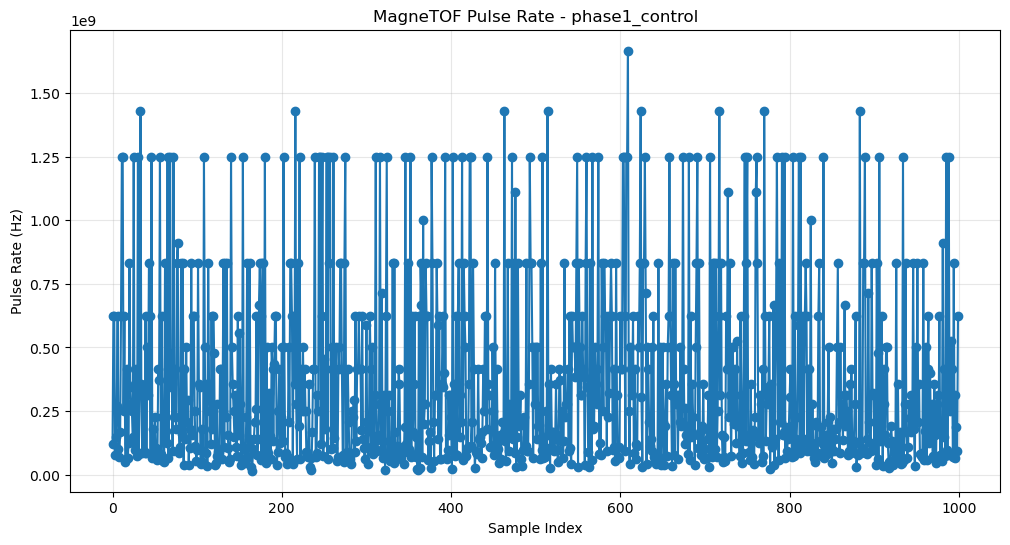

Plot saved to: Results/phase1_control_20260618_121209_frequency.png


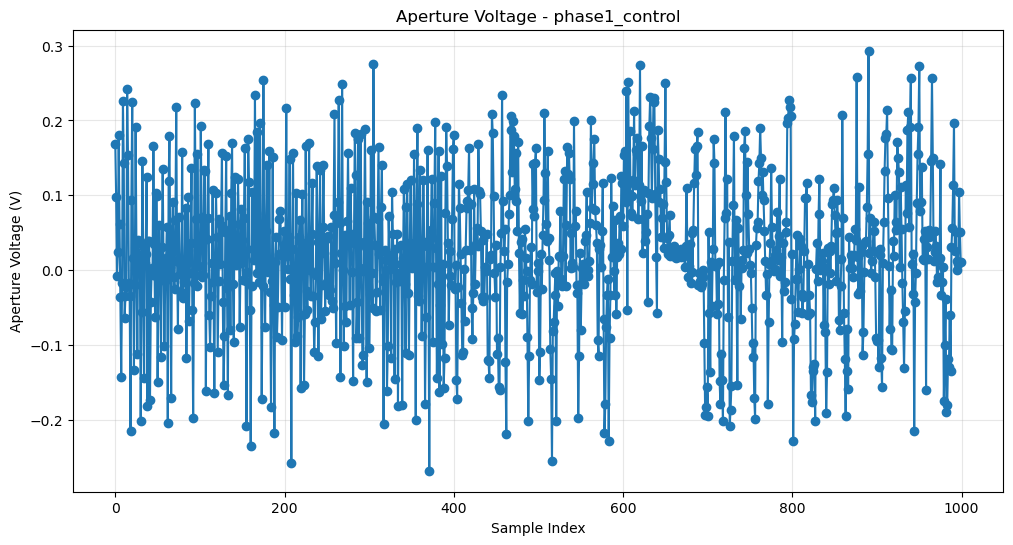

Plot saved to: Results/phase1_control_20260618_121209_aperture_voltage.png

 Run Summary for phase1_control:
 Total Samples: 1000
     Mean rate: 367085065.50 Hz
     Std Dev: 357616064.93 Hz
     Mean Aperture Voltage: 0.02 V
VISA connection closed.


In [19]:
def print_summary(df):
    print(f"\n Run Summary for {EXPERIMENT_PHASE}:")
    print(f" Total Samples: {len(df)}")

    freq = df["frequency_hz"].dropna()
    if not freq.empty:
        print(f"     Mean rate: {freq.mean():.2f} Hz")
        print(f"     Std Dev: {freq.std():.2f} Hz")
    
    apv = df["aperture_voltage"].dropna()
    if not apv.empty:
        print(f"     Mean Aperture Voltage: {apv.mean():.2f} V")

if __name__ == "__main__":
    os.makedirs(OUTPUT_DIR, exist_ok=True) # Ensure output directory exists
    scope = None
    try:
        scope = connect(VISA_RESOURCE)
        setup_scope(scope)

        print("Waiting 3s for settings to stabilize...")
        time.sleep(3)

        data_df = acquire_data(scope)
        if not data_df.empty:
            save_data(data_df)
            generate_plots(data_df)
            print_summary(data_df)
        else:
            print("No data acquired.")

    except pyvisa.errors.VisaIOError as e:
        print(f"\n VISA Communication Error: {e}")
        print(" Please check the connection and VISA resource string.")

    finally:
        if scope is not None:
            scope.write("acquire:state run") 
            scope.close()
            print("VISA connection closed.")